In [86]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker


In [3]:
PRECLINICAL_ANNOTATIONS_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_data_enriched.csv"
preclin_data = pd.read_csv(PRECLINICAL_ANNOTATIONS_PATH)
preclin_data = preclin_data.drop_duplicates(subset=["PMID"])
preclin_data.shape

(547365, 9)

In [5]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

In [6]:
preclin_data = preclin_data.merge(metadata_df_year, on="PMID", how="left")

,PMID,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,linkbert_mapped_conditions,linkbert_mapped_drugs,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,year
0,31733831,asthma,isorhynchophylline,asthma,isorhynchophylline,asthma,MONDO:0004979,isorhynchophylline,C0245133,2020.0
1,31733833,myocardial infarction,antgomir-1192|mir-1192|agomir-1192,myocardial infarction,antgomir-1192|mir-1192|agomir-1192,myocardial infarction,MONDO:0005068,antgomir-1192|mir-1192|agomir-1192,-1|-1|-1,2020.0
2,31733925,systemic lupus erythematosus,g2|hla-g2,systemic lupus erythematosus,g2|hla-g2,systemic lupus erythematosus,MONDO:0007915,g2|HLA-G2 Isoform,-1|C0967254,2020.0
3,31733940,cognitive impairment,minocycline,cognitive impairment,minocycline,cognitive disorder,MONDO:0002039,Minocycline,C0026187,2020.0
4,31734027,oxaliplatin-induced peripheral neuropathy|cumu...,tadalafil|phosphodiesterase type 5 inhibitor t...,oxaliplatin-induced peripheral neuropathy|cumu...,tadalafil|phosphodiesterase type 5 inhibitor t...,oxaliplatin-induced peripheral neuropathy|cumu...,-1|-1|MONDO:0003620,Tadalafil|Tadalafil,C1176316|C1176316,2019.0


In [67]:
import re

JUNK_PATTERNS = [
    r'^\s*["\']?\s*#?\s*\d+\s*[,"\']?\s*$',  # " 528', '# 0451', '# 2714', 528, 1,234
]

def _is_junk_token(tok: str) -> bool:
    """Return True if token is meaningless junk like '# 0451', '" 528\'', '()', etc."""
    s = tok.strip().strip('"').strip("'").strip()

    # Empty or one-character junk
    if not s or len(s) < 2:
        return True

    # Pure punctuation / brackets / quotes / plus/minus
    if re.fullmatch(r"^[\(\)\[\]\{\}\'\"\,\.\#\s\-\_\+\=]+$", s):
        return True

    # Numeric garbage possibly prefixed/suffixed by punctuation
    if re.fullmatch(r'^[#\s\'\"\(\)\+\-]*\d+[\'\"\)\s,]*$', s):
        return True

    # Hash-prefixed or leading garbage like '# #', '# 0451'
    if s.startswith("#") and not re.search(r"[A-Za-z]", s):
        return True

    # Junk like empty parentheses or stray symbols
    if s in {"()", "( )", "''", '""', "''", "'"}:
        return True

    return False


def clean_predictions(drugs_list: str) -> str:
    """
    Clean and normalize a pipe-separated list of drug names.
    Removes artifacts (like '# # 45-65-nh2', '" 528'), filters mechanistic terms,
    and maps known synonyms to canonical drug names.
    Keeps valid names like 'mir-1192' or 'antagomir-21' intact.
    """
    if not isinstance(drugs_list, str) or not drugs_list.strip():
        return drugs_list

    drug_names = drugs_list.split("|")
    drug_names_clean = set()

    for drug_name in drug_names:
        dn = drug_name.strip().strip('"').strip("'").strip()

        # Junk or meaningless tokens
        if _is_junk_token(dn):
            continue

        # Skip mechanistic/generic category terms
        if any(word in dn.lower() for word in [
            "antibody", "channel", "receptor", "modulator",
            "blocker", "agonist", "antagonis", "anti-", "inhibitor"
        ]):
            continue

        # Canonical name mappings (case-insensitive)
        ln = dn.lower()
        if ln in ["fty720-c2", "fingolimod-1 phosphate"]:
            dn = "Fingolimod"
        elif ln in [
            "1,25-dihydroxyvitamin d", "1alpha,25-dihydroxyvitamin d",
            "vitamin d", "vitamin d3", "calcitriol", "cholecalciferol"
        ]:
            dn = "vitamin D3"
        elif ln in ["beta interferon", "interferon beta (recombinant)"]:
            dn = "beta 1 Interferon"

        # Valid alphanumeric-hyphen pattern (keep mir-1192, agomir-21, etc.)
        if not re.match(r'^[A-Za-z0-9\-\s\(\)]+$', dn):
            continue

        # Too short or empty
        if not dn or len(dn) < 2:
            continue

        drug_names_clean.add(dn)

    # Return cleaned list or fallback to original
    return "|".join(sorted(drug_names_clean)) if drug_names_clean else drugs_list


In [68]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq


In [69]:
preclin_data["drug_term_umls_norm_manual_clean"] = preclin_data['drug_term_umls_norm'].apply(lambda x: clean_predictions(x))
preclin_data.head()

,PMID,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,linkbert_mapped_conditions,linkbert_mapped_drugs,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,year,drug_term_umls_norm_manual_clean
0,31733831,asthma,isorhynchophylline,asthma,isorhynchophylline,asthma,MONDO:0004979,isorhynchophylline,C0245133,2020.0,isorhynchophylline
1,31733833,myocardial infarction,antgomir-1192|mir-1192|agomir-1192,myocardial infarction,antgomir-1192|mir-1192|agomir-1192,myocardial infarction,MONDO:0005068,antgomir-1192|mir-1192|agomir-1192,-1|-1|-1,2020.0,agomir-1192|antgomir-1192|mir-1192
2,31733925,systemic lupus erythematosus,g2|hla-g2,systemic lupus erythematosus,g2|hla-g2,systemic lupus erythematosus,MONDO:0007915,g2|HLA-G2 Isoform,-1|C0967254,2020.0,HLA-G2 Isoform|g2
3,31733940,cognitive impairment,minocycline,cognitive impairment,minocycline,cognitive disorder,MONDO:0002039,Minocycline,C0026187,2020.0,Minocycline
4,31734027,oxaliplatin-induced peripheral neuropathy|cumu...,tadalafil|phosphodiesterase type 5 inhibitor t...,oxaliplatin-induced peripheral neuropathy|cumu...,tadalafil|phosphodiesterase type 5 inhibitor t...,oxaliplatin-induced peripheral neuropathy|cumu...,-1|-1|MONDO:0003620,Tadalafil|Tadalafil,C1176316|C1176316,2019.0,Tadalafil


In [70]:
n_unique, freq = count_unique_from_pipe_column(preclin_data, "drug_term_umls_norm")
print(f"Unique count: {n_unique}")

Unique count: 335316


In [71]:
n_unique, freq = count_unique_from_pipe_column(preclin_data, "drug_term_umls_norm_manual_clean")
print(f"Unique count: {n_unique}")

Unique count: 218510


In [72]:
freq

,drug_term_umls_norm_manual_clean,n_articles
23191,Dexamethasone,5865
18687,Acetylcysteine,4463
23520,Doxorubicin,4411
30933,NG-Nitroarginine Methyl Ester,4166
36209,Sirolimus,3839
...,...,...
89020,diarylaminopropylamine derivative,1
89021,diarylbenzopyrimidine,1
89022,diarylbenzopyrimidine analogues,1
89023,diarylcoumarins,1


In [73]:
save_path = f"out/unique_drug_terms_{n_unique}.csv"
freq.to_csv(save_path, index=False)

## Build table

In [74]:
def create_df_for_plotting(df,
                           drug_col="Tested drug(s)",
                           year_col="year",
                           pmid_col="PMID",
                           year_range=(2000, 2024)):
    """
    Returns a wide table: rows=drug names, cols=years in range, values=unique article counts (PMID nunique).
    Assumes pipe-separated drugs in `drug_col`.
    """

    # 1) Keep only years in range
    y0, y1 = year_range
    df = df[pd.to_numeric(df[year_col], errors="coerce").between(y0, y1)].copy()
    missing_years = df[year_col].isna().sum()
    if missing_years:
        print(f"[INFO] Dropped {missing_years} rows with missing or invalid '{year_col}' values.")
        
    # 2) Split drugs by '|' and explode to long
    #    - handle NaN / blanks / "not-reported"
    parts = (df[drug_col]
             .astype(str)
             .str.split(r"\s*\|\s*"))
    df_long = df[[pmid_col, year_col]].copy()
    df_long[drug_col] = parts
    df_long = df_long.explode(drug_col, ignore_index=True)

    # 3) Clean drug strings and drop invalid
    def _clean(x):
        x = (x or "").strip()
        return x
    df_long[drug_col] = df_long[drug_col].map(_clean)
    bad = {"", "nan", "none", "not-reported", "not reported"}
    df_long = df_long[~df_long[drug_col].str.lower().isin(bad)]

    # 4) Count unique PMIDs per drug-year
    counts = (df_long
              .drop_duplicates([pmid_col, drug_col, year_col])
              .groupby([drug_col, year_col])[pmid_col]
              .nunique()
              .rename("count")
              .reset_index())

    # 5) Pivot to wide with full year columns
    all_years = list(range(y0, y1 + 1))
    wide = (counts
            .pivot(index=drug_col, columns=year_col, values="count")
            .reindex(columns=all_years)
            .fillna(0)
            .astype(int))

    # 6) Optional: sort rows by total desc
    wide["Total"] = wide.sum(axis=1)
    wide = wide.sort_values("Total", ascending=False)

    return wide

In [78]:
all_drugs_timeline = create_df_for_plotting(preclin_data, drug_col="drug_term_umls_norm_manual_clean", year_col="year", pmid_col="PMID", year_range=(1979, 2024))
all_drugs_timeline.head()

year,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
drug_term_umls_norm_manual_clean,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,29,26,31,24,32,32,44,45,49,45,...,215,184,207,212,198,226,228,168,190,5781
Acetylcysteine,1,4,4,4,6,11,19,18,14,17,...,194,193,213,210,226,206,204,188,176,4454
Doxorubicin,7,15,22,12,19,39,12,24,22,28,...,230,196,256,274,261,232,246,222,189,4378
NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,0,...,91,79,79,83,85,62,57,37,34,4164
Sirolimus,0,0,0,0,1,0,0,0,0,0,...,209,205,241,259,274,278,244,216,214,3824


In [79]:
all_drugs_timeline.shape

(216142, 47)

In [106]:
all_drugs_timeline.to_csv("out/all_drugs_articles_timeline.csv")

## VIZ

In [93]:
def _size_transform(vals, mode="absolute", scale=40, eps=1e-9):
    v = np.asarray(vals, dtype=float)
    if mode == "absolute":              # current behavior
        sz = v * scale
    elif mode == "sqrt":                 # good for wide ranges
        sz = np.sqrt(v) * scale
    elif mode == "log":                  # very aggressive compression
        sz = np.log1p(v) * scale
    elif mode == "row_percent":          # relative to per-drug max
        denom = v.max() if np.isfinite(v.max()) and v.max() > 0 else 1.0
        sz = (v / (denom + eps)) * scale
    else:
        raise ValueError("size_mode must be one of: absolute|sqrt|log|row_percent")
    return sz


In [103]:
def plot_drug_year_bubbles_from_wide(
    drug_years: dict,
    wide_df: pd.DataFrame,             # rows=drug names, cols=years (int/str) and maybe 'Total'
    title: str = "Timeline of studies for drugs",
    output_file: str | None = None,
    drugs_custom_order: list | None = None,
    year_range: tuple[int, int] | None = None,
    scale: int = 20
):
    """
    Plot a bubble timeline using a wide table of unique-PMID counts per drug-year.
    - Includes drugs even if approval year is missing; approval marker drawn only when available.
    """

    # 1) Detect year columns
    year_cols = []
    for c in wide_df.columns:
        try:
            y = int(c)
            year_cols.append(y)
        except (TypeError, ValueError):
            pass
    year_cols = sorted(set(year_cols))
    if not year_cols:
        raise ValueError("No year columns detected in `wide_df` (columns must be years or castable to int).")

    if year_range:
        y0, y1 = year_range
        year_cols = [y for y in year_cols if y0 <= y <= y1]

    # Ensure numeric counts, fill NaNs
    for y in year_cols:
        wide_df.loc[:, y] = (
            pd.to_numeric(wide_df.get(y, 0), errors="coerce")
            .fillna(0)
            .astype(int)
        )
    # 2) Choose drugs to plot (use custom order if given; else all index)
    if drugs_custom_order:
        drugs_in_order = [d for d in drugs_custom_order if d in wide_df.index]
    else:
        drugs_in_order = list(wide_df.index)

    n_drugs = len(drugs_in_order)
    print(f"Plotting {n_drugs} drugs")
    if n_drugs == 0:
        raise ValueError("No drugs to plot (check `wide_df.index` and/or `drugs_custom_order`).")

    # 3) Figure and axes
    fig_height = max(4, 0.75 * n_drugs)
    plt.figure(figsize=(12, fig_height))
    ax = plt.gca()

    # 4) Plot per drug (top-to-bottom)
    for i, drug in enumerate(drugs_in_order):
        y_pos = n_drugs - 1 - i
        row = wide_df.loc[drug, year_cols]

        nonzero = row[row > 0]
        if nonzero.empty:
            continue

        size_mode = "absolute"        # or "log" or "row_percent"
        # compute bubble sizes with chosen transform
        sizes = _size_transform(nonzero.values, mode=size_mode, scale=scale)
    
        ax.scatter(
            nonzero.index.astype(int),
            np.full(len(nonzero), y_pos),
            s=sizes,
            alpha=0.7,
        )

        # Labels on bubbles
        for yr, n in nonzero.items():
            ax.text(int(yr), y_pos, int(n), ha="center", va="center", fontsize=8, zorder=3)

        # Approval marker ONLY if available and valid
        appr_year = drug_years.get(drug, None)
        if appr_year:
            try:
                ay = int(appr_year)
                # Thicker dashed line and larger diamond marker in grey
                ax.plot(
                    [ay, ay],
                    [y_pos - 0.4, y_pos + 0.4],
                    linestyle="--",
                    color="grey",
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=3,
                )
                ax.scatter(
                    [ay],
                    [y_pos],
                    marker="D",
                    s=70,            # bigger diamond
                    color="grey",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
            except (TypeError, ValueError):
                pass  # ignore non-int-like values

    # 5) Axis styling
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.set_yticks(range(n_drugs))
    ax.set_yticklabels(list(reversed(drugs_in_order)), fontsize=16)
    ax.set_ylim(-1, n_drugs)
    ax.set_xlim(min(year_cols) - 0.5, max(year_cols) + 0.5)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    plt.xlabel("Publication year", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

    plt.show()

Plotting 20 drugs
Saved plot to: viz/top_10_drug_timeline_preclinical.png


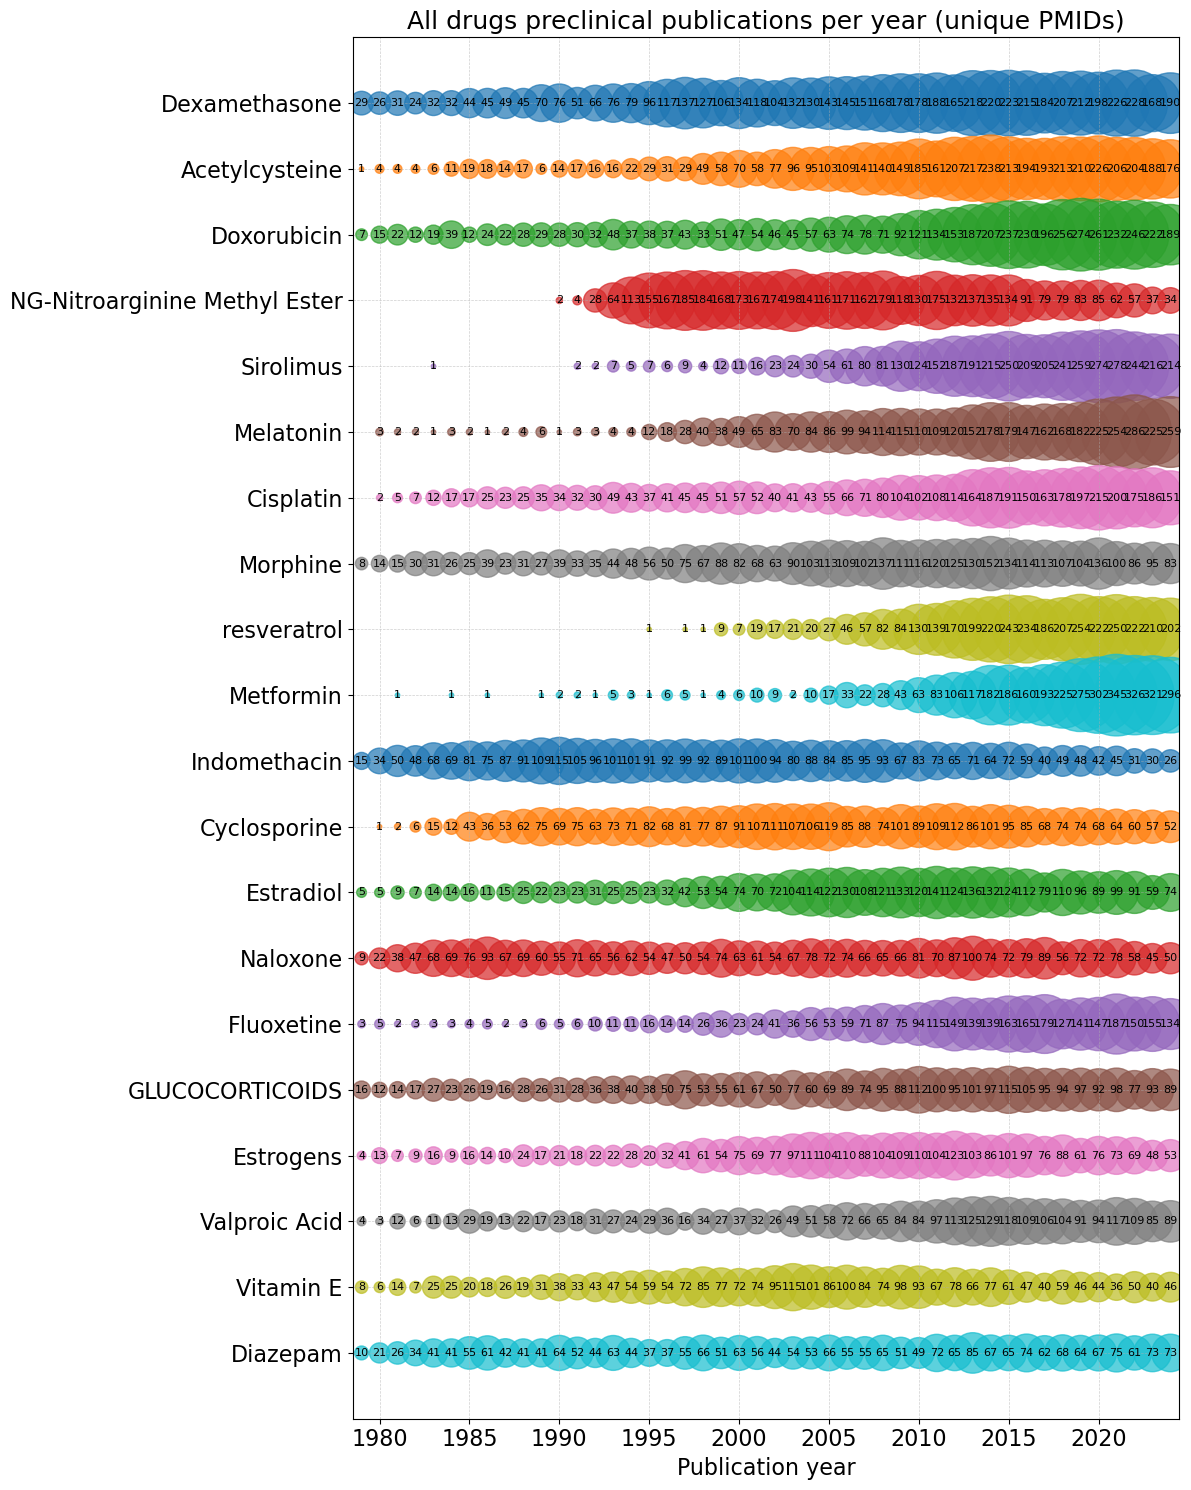

In [105]:
plot_drug_year_bubbles_from_wide(
    drug_years={},
    wide_df=all_drugs_timeline.head(20),
    title="All drugs preclinical publications per year (unique PMIDs)",
    output_file="viz/top_10_drug_timeline_preclinical.png",
    #drugs_custom_order=approved_drugs_list,  # optional
    year_range=(1979, 2024),
    scale=10
)